# Image Preprocessing

## Import Libraries

In [1]:
import os
import cv2
import random
import tempfile
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

## Set Dataset Path

In [2]:
input_folder = "../Clean_Dataset"
output_folder = "../Preprocessed_Dataset"

os.makedirs(output_folder, exist_ok=True)

print("Input :", input_folder)
print("Output:", output_folder)

Input : ../Clean_Dataset
Output: ../Preprocessed_Dataset


## Load Dataset

In [3]:
classes = [
    folder
    for folder in os.listdir(input_folder)
    if os.path.isdir(os.path.join(input_folder, folder))
]

print("Classes:", classes)

images = []

for cls in classes:

    class_path = os.path.join(
        input_folder,
        cls
    )

    files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    for file in files:
        images.append((cls, file))

print("Total Images:", len(images))

Classes: ['Missing_hole_rotation', 'Mouse_bite_rotation', 'Open_circuit_rotation', 'Short_rotation', 'Spurious_copper_rotation', 'Spur_rotation']
Total Images: 693


### Select Sample Image

In [4]:
sample_class = random.choice(classes)

sample_folder = os.path.join(
    input_folder,
    sample_class
)

sample_file = random.choice([
    f for f in os.listdir(sample_folder)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])

sample_path = os.path.join(
    sample_folder,
    sample_file
)

original = cv2.imread(sample_path)

print("Class:", sample_class)
print("Image:", sample_file)

Class: Spurious_copper_rotation
Image: 04_spurious_copper_14.jpg


## Colour Normalisation

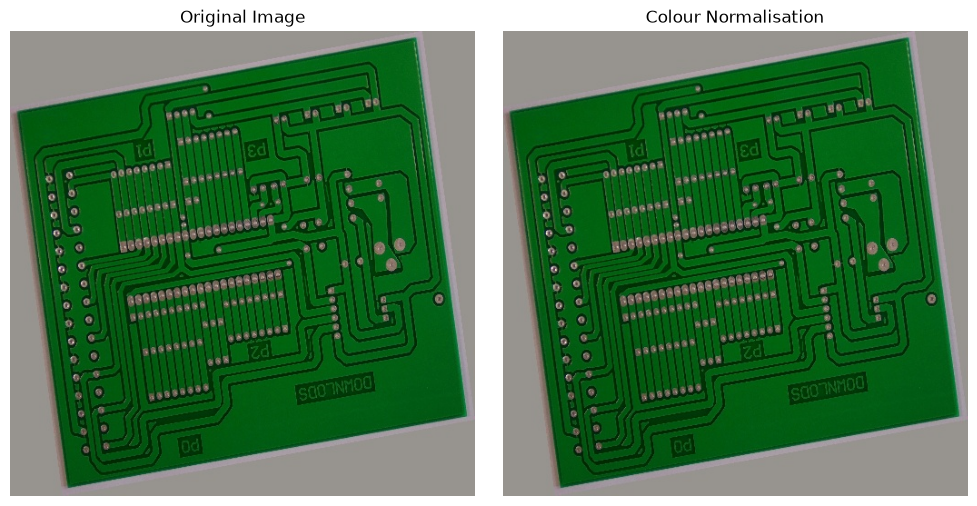

In [5]:
normalised = cv2.normalize(
    original,
    None,
    0,
    255,
    cv2.NORM_MINMAX
)

original_rgb = cv2.cvtColor(
    original,
    cv2.COLOR_BGR2RGB
)

normalised_rgb = cv2.cvtColor(
    normalised,
    cv2.COLOR_BGR2RGB
)

plt.figure(
    figsize=(10, 5)
)

plt.subplot(
    1, 2, 1
)

plt.imshow(
    original_rgb
)

plt.title(
    "Original Image"
)

plt.axis("off")


plt.subplot(
    1, 2, 2
)

plt.imshow(
    normalised_rgb
)

plt.title(
    "Colour Normalisation"
)

plt.axis("off")

plt.tight_layout()

plt.show()

## Gaussian Filter

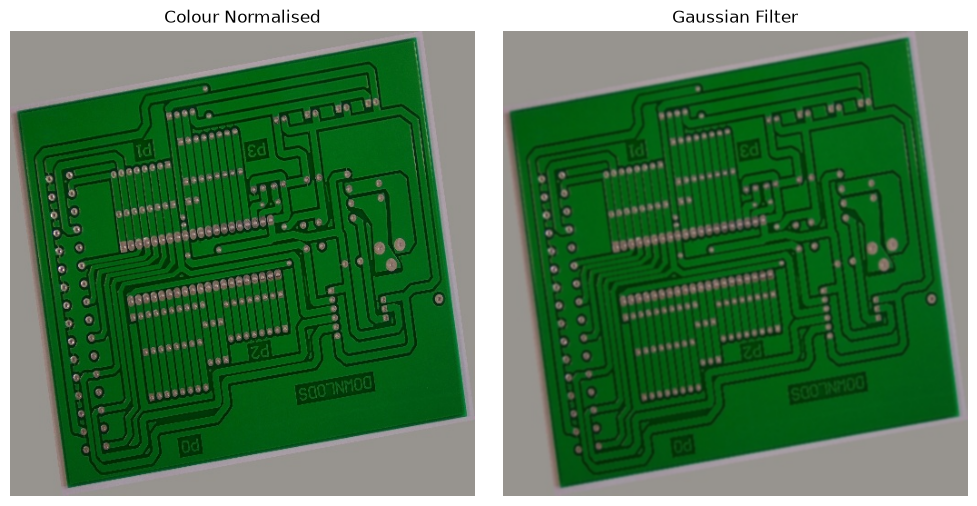

In [6]:
gaussian = cv2.GaussianBlur(
    normalised,
    (5, 5),
    0
)

gaussian_rgb = cv2.cvtColor(
    gaussian,
    cv2.COLOR_BGR2RGB
)

plt.figure(
    figsize=(10, 5)
)

plt.subplot(
    1, 2, 1
)

plt.imshow(
    normalised_rgb
)

plt.title(
    "Colour Normalised"
)

plt.axis("off")


plt.subplot(
    1, 2, 2
)

plt.imshow(
    gaussian_rgb
)

plt.title(
    "Gaussian Filter"
)

plt.axis("off")

plt.tight_layout()

plt.show()

## Gaussian Filter Kernel Matrix


In [7]:
# Original 5 × 5 Gaussian Kernel

gaussian_kernel_raw = np.array([
    [1,  4,  7,  4,  1],
    [4, 16, 26, 16,  4],
    [7, 26, 41, 26,  7],
    [4, 16, 26, 16,  4],
    [1,  4,  7,  4,  1]
], dtype=np.float32)


# Normalise the kernel

gaussian_kernel = (
    gaussian_kernel_raw /
    gaussian_kernel_raw.sum()
)


print("Original 5 × 5 Gaussian Kernel:")
print(gaussian_kernel_raw)

print(
    "\nNormalised 5 × 5 Gaussian Kernel:"
)

print(
    gaussian_kernel
)

Original 5 × 5 Gaussian Kernel:
[[ 1.  4.  7.  4.  1.]
 [ 4. 16. 26. 16.  4.]
 [ 7. 26. 41. 26.  7.]
 [ 4. 16. 26. 16.  4.]
 [ 1.  4.  7.  4.  1.]]

Normalised 5 × 5 Gaussian Kernel:
[[0.003663   0.01465201 0.02564103 0.01465201 0.003663  ]
 [0.01465201 0.05860806 0.0952381  0.05860806 0.01465201]
 [0.02564103 0.0952381  0.15018316 0.0952381  0.02564103]
 [0.01465201 0.05860806 0.0952381  0.05860806 0.01465201]
 [0.003663   0.01465201 0.02564103 0.01465201 0.003663  ]]


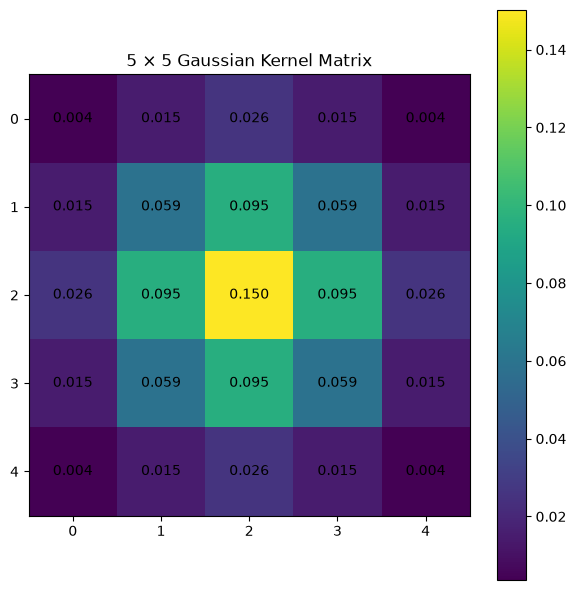

In [8]:
plt.figure(
    figsize=(6, 6)
)

plt.imshow(
    gaussian_kernel
)

plt.colorbar()

plt.title(
    "5 × 5 Gaussian Kernel Matrix"
)

for i in range(5):

    for j in range(5):

        plt.text(
            j,
            i,
            f"{gaussian_kernel[i, j]:.3f}",
            ha="center",
            va="center"
        )

plt.xticks(
    range(5)
)

plt.yticks(
    range(5)
)

plt.tight_layout()

plt.show()

## Gaussian Kernel Application

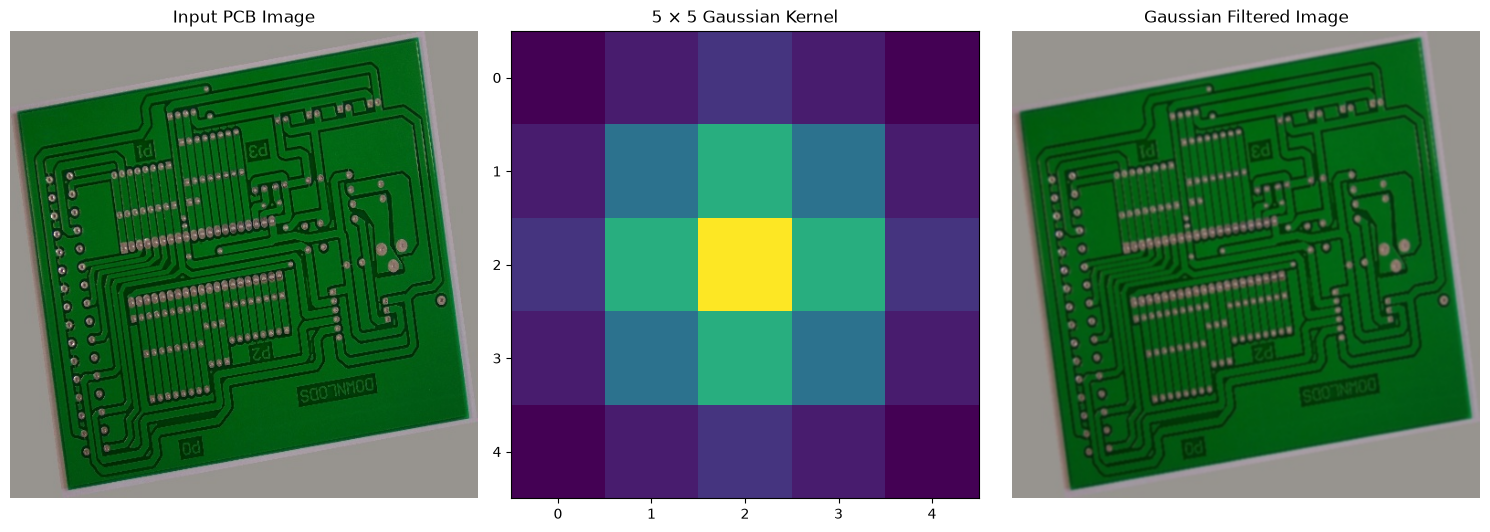

In [9]:
plt.figure(
    figsize=(15, 5)
)

# Input PCB

plt.subplot(
    1, 3, 1
)

plt.imshow(
    normalised_rgb
)

plt.title(
    "Input PCB Image"
)

plt.axis("off")


# Gaussian Kernel

plt.subplot(
    1, 3, 2
)

plt.imshow(
    gaussian_kernel
)

plt.title(
    "5 × 5 Gaussian Kernel"
)

plt.xticks(
    range(5)
)

plt.yticks(
    range(5)
)


# Filtered Image

plt.subplot(
    1, 3, 3
)

plt.imshow(
    gaussian_rgb
)

plt.title(
    "Gaussian Filtered Image"
)

plt.axis("off")


plt.tight_layout()

plt.show()

## CLAHE Demonstration

L Channel: (512, 512)
A Channel: (512, 512)
B Channel: (512, 512)
L Channel: (512, 512)
A Channel: (512, 512)
B Channel: (512, 512)


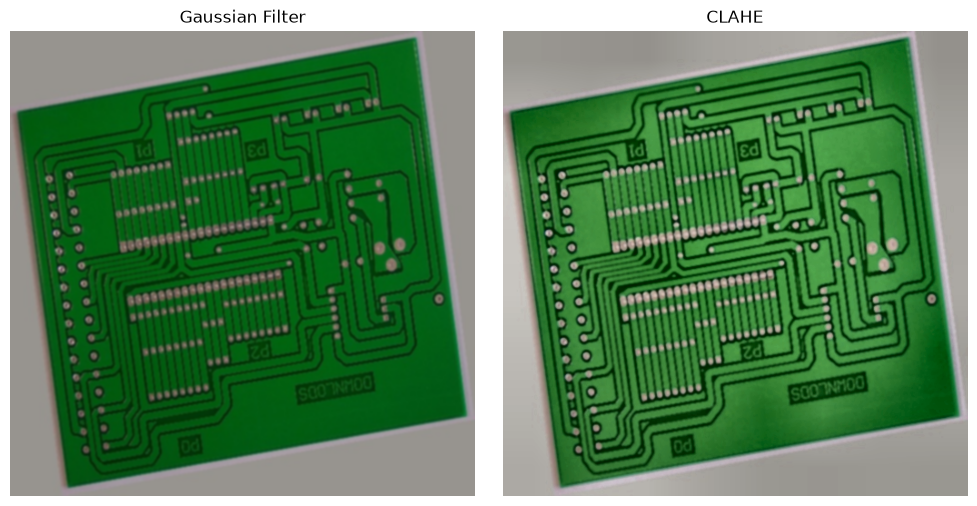

In [10]:
lab = cv2.cvtColor(
    gaussian,
    cv2.COLOR_BGR2LAB
)

l, a, b = cv2.split(
    lab
)

print(
    "L Channel:",
    l.shape
)

print(
    "A Channel:",
    a.shape
)

print(
    "B Channel:",
    b.shape
)

l, a, b = cv2.split(lab)

print("L Channel:", l.shape)
print("A Channel:", a.shape)
print("B Channel:", b.shape)

clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8, 8)
)

l_clahe = clahe.apply(
    l
)

lab_clahe = cv2.merge(
    (
        l_clahe,
        a,
        b
    )
)

processed = cv2.cvtColor(
    lab_clahe,
    cv2.COLOR_LAB2BGR
)

processed_rgb = cv2.cvtColor(
    processed,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(gaussian_rgb)
plt.title("Gaussian Filter")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(processed_rgb)
plt.title("CLAHE")
plt.axis("off")

plt.tight_layout()
plt.show()

## CLAHE 8 × 8 Tile Grid

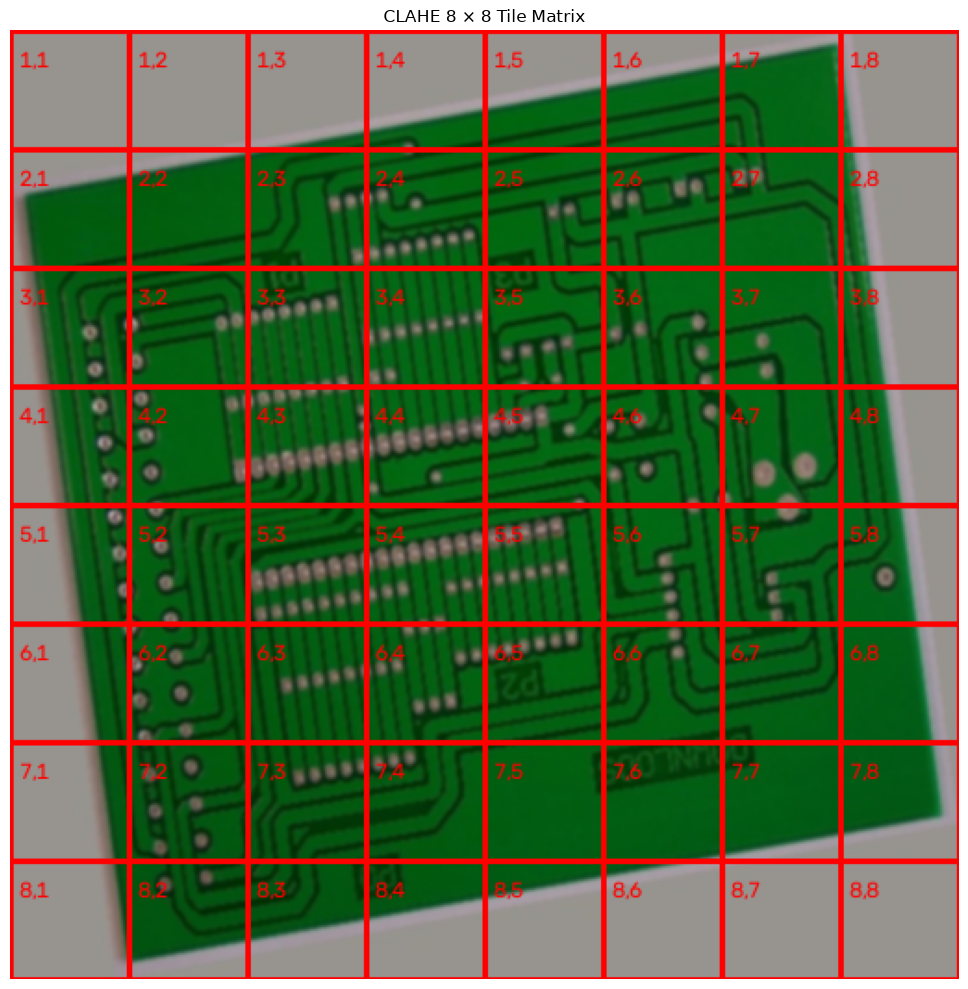

In [11]:
# Create a copy of the Gaussian-filtered image

clahe_grid_image = gaussian.copy()


# Convert BGR to RGB

clahe_grid_image = cv2.cvtColor(
    clahe_grid_image,
    cv2.COLOR_BGR2RGB
)


# Get image dimensions

height, width = (
    clahe_grid_image.shape[:2]
)


# Draw 8 × 8 tile grid

for row in range(8):

    for col in range(8):

        x1 = int(
            width * col / 8
        )

        y1 = int(
            height * row / 8
        )

        x2 = int(
            width * (col + 1) / 8
        )

        y2 = int(
            height * (row + 1) / 8
        )


        # Draw tile boundary

        cv2.rectangle(
            clahe_grid_image,
            (x1, y1),
            (x2, y2),
            (255, 0, 0),
            2
        )


        # Tile number

        cv2.putText(
            clahe_grid_image,
            f"{row + 1},{col + 1}",
            (x1 + 5, y1 + 20),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.4,
            (255, 0, 0),
            1
        )


plt.figure(
    figsize=(10, 10)
)

plt.imshow(
    clahe_grid_image
)

plt.title(
    "CLAHE 8 × 8 Tile Matrix"
)

plt.axis("off")

plt.tight_layout()

plt.show()

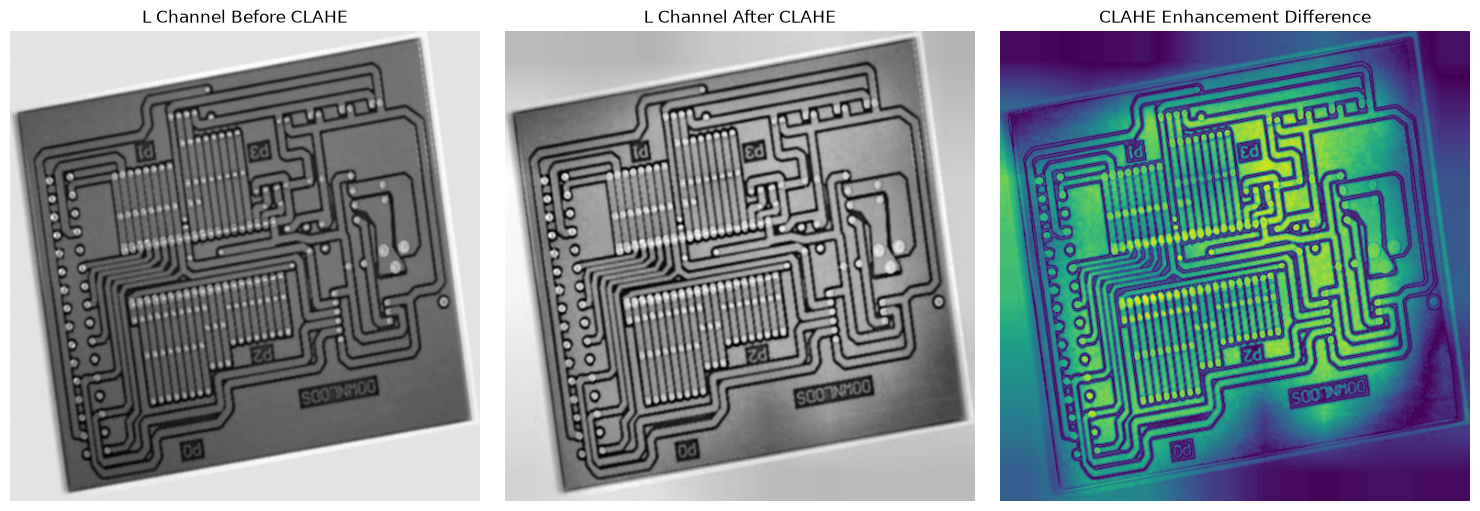

In [12]:
## CLAHE L Channel Comparison

plt.figure(figsize=(15, 5))

# Original L Channel
plt.subplot(1, 3, 1)

plt.imshow(
    l,
    cmap="gray"
)

plt.title(
    "L Channel Before CLAHE"
)

plt.axis("off")


# CLAHE L Channel
plt.subplot(1, 3, 2)

plt.imshow(
    l_clahe,
    cmap="gray"
)

plt.title(
    "L Channel After CLAHE"
)

plt.axis("off")


# Difference
difference = cv2.absdiff(
    l_clahe,
    l
)

plt.subplot(1, 3, 3)

plt.imshow(
    difference,
)

plt.title(
    "CLAHE Enhancement Difference"
)

plt.axis("off")

plt.tight_layout()

plt.show()

### Full Processing Pipeline

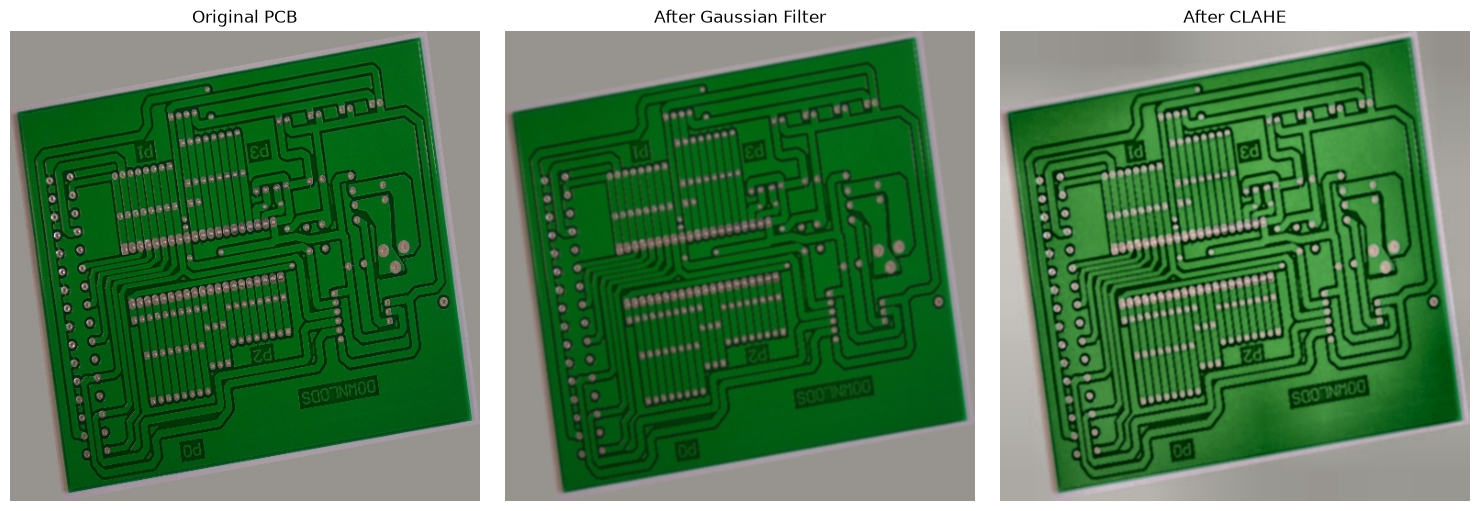

In [13]:
plt.figure(
    figsize=(15, 5)
)


# Original

plt.subplot(
    1, 3, 1
)

plt.imshow(
    original_rgb
)

plt.title(
    "Original PCB"
)

plt.axis("off")


# Gaussian

plt.subplot(
    1, 3, 2
)

plt.imshow(
    gaussian_rgb
)

plt.title(
    "After Gaussian Filter"
)

plt.axis("off")


# CLAHE

plt.subplot(
    1, 3, 3
)

plt.imshow(
    processed_rgb
)

plt.title(
    "After CLAHE"
)

plt.axis("off")


plt.tight_layout()

plt.show()

## Image Preprocessing

In [ ]:
processed_images = 0
skipped_images = 0

for cls, file in images:

    img_path = os.path.join(
        input_folder,
        cls,
        file
    )

    img = cv2.imread(img_path)

    if img is None:
        skipped_images += 1
        continue

    # Colour Normalisation
    img = cv2.normalize(
        img,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    )

    # Gaussian Filter
    gaussian = cv2.GaussianBlur(
        img,
        (5, 5),
        0
    )

    # Convert BGR to LAB
    lab = cv2.cvtColor(
        gaussian,
        cv2.COLOR_BGR2LAB
    )

    # Split LAB channels
    l, a, b = cv2.split(lab)

    # CLAHE
    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    l = clahe.apply(l)

    # Merge LAB channels
    lab = cv2.merge(
        (l, a, b)
    )

    # Convert LAB back to BGR
    processed = cv2.cvtColor(
        lab,
        cv2.COLOR_LAB2BGR
    )

    # Create output folder
    save_folder = os.path.join(
        output_folder,
        cls
    )

    os.makedirs(
        save_folder,
        exist_ok=True
    )

    # Save processed image
    save_path = os.path.join(
        save_folder,
        file
    )

    cv2.imwrite(
        save_path,
        processed
    )

    processed_images += 1

print("Image Preprocessing Completed!")

Image Preprocessing Completed!


## Display Before & After

Original Path:
../Clean_Dataset\Spurious_copper_rotation\04_spurious_copper_14.jpg

Processed Path:
../Preprocessed_Dataset\Spurious_copper_rotation\04_spurious_copper_14.jpg

Image Exists: True


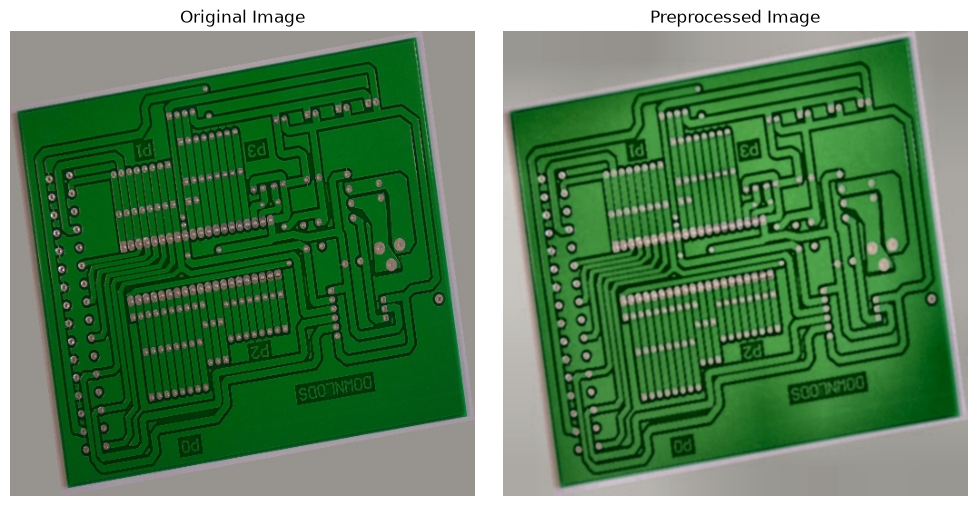

In [15]:
processed_path = os.path.join(
    output_folder,
    sample_class,
    sample_file
)

print("Original Path:")
print(sample_path)

print("\nProcessed Path:")
print(processed_path)

print(
    "\nImage Exists:",
    os.path.exists(processed_path)
)

original = cv2.imread(sample_path)

processed = cv2.imread(processed_path)

original = cv2.cvtColor(
    original,
    cv2.COLOR_BGR2RGB
)

processed = cv2.cvtColor(
    processed,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(original)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(processed)
plt.title("Preprocessed Image")
plt.axis("off")

plt.tight_layout()
plt.show()

## Histogram Demonstration

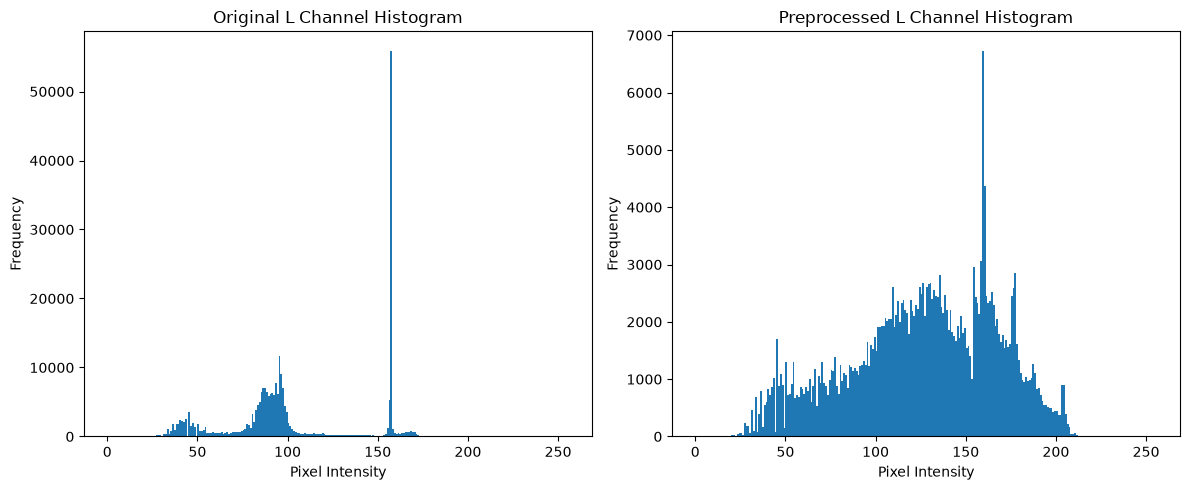

In [16]:
original_bgr = cv2.imread(sample_path)
processed_bgr = cv2.imread(processed_path)

original_lab = cv2.cvtColor(
    original_bgr,
    cv2.COLOR_BGR2LAB
)

processed_lab = cv2.cvtColor(
    processed_bgr,
    cv2.COLOR_BGR2LAB
)

original_l, _, _ = cv2.split(original_lab)
processed_l, _, _ = cv2.split(processed_lab)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.hist(
    original_l.ravel(),
    bins=256,
    range=(0, 256)
)

plt.title("Original L Channel Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)

plt.hist(
    processed_l.ravel(),
    bins=256,
    range=(0, 256)
)

plt.title("Preprocessed L Channel Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## Summary

In [17]:
print("========== Preprocessed Dataset Summary ==========")

processed_images = 0

for cls in classes:

    folder = os.path.join(
        output_folder,
        cls
    )

    if not os.path.exists(folder):
        print(f"{cls}: 0")
        continue

    count = len([
        f for f in os.listdir(folder)
        if f.lower().endswith(
            (".jpg", ".jpeg", ".png")
        )
    ])

    processed_images += count

    print(f"{cls}: {count}")

print("-------------------------------------")
print("Total Images     :", len(images))
print("Processed Images :", processed_images)
print("Skipped Images   :", skipped_images)

========== Preprocessed Dataset Summary ==========
Missing_hole_rotation: 115
Mouse_bite_rotation: 115
Open_circuit_rotation: 116
Short_rotation: 116
Spurious_copper_rotation: 116
Spur_rotation: 115
-------------------------------------
Total Images     : 693
Processed Images : 693
Skipped Images   : 0


### Core Preprocessing Function

In [18]:
def preprocess_image(img):
    
    # Applies preprocessing to the input image:
    # Colour Normalisation -> Gaussian Filter -> CLAHE
    # Returns the processed image.
    
    if img is None:
        print("Error: Input image is empty.")
        return None

    # 1. Colour Normalisation
    normalised = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)

    # 2. Gaussian Filter
    gaussian = cv2.GaussianBlur(normalised, (5, 5), 0)

    # 3. Convert to LAB color space for CLAHE
    lab = cv2.cvtColor(gaussian, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    # Apply CLAHE to the L-channel
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l_clahe = clahe.apply(l)

    # Merge channels and convert back to BGR
    lab_clahe = cv2.merge((l_clahe, a, b))
    processed = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2BGR)

    return processed

print("Preprocess function loaded successfully!")

Preprocess function loaded successfully!


### ROI Detection

`preprocess_image()` above was tuned for a 512 x 512 cropped board, and both of its
main steps depend on **what else is in the frame**:

- `cv2.normalize(..., NORM_MINMAX)` takes min/max over the whole image. On a full
  conveyor frame the white background (255) and dark board border (0) already span
  the range, so it becomes a **no-op (measured 0.00 mean change)**. On a cropped
  board it does real work (3.68).
- `CLAHE(tileGridSize=(8,8))` splits whatever it is given into 8 x 8 tiles.
  512 x 512 gives 64 x 64 tiles inside the board; 1280 x 720 gives 160 x 90 tiles,
  each **wider than the whole 180 px PCB**.

So the board must be cropped out **before** filtering, not after. Measured difference
between the two orderings on a real frame: mean abs 19/255, max 118.

PCB copper is strongly coloured; belts, desks and paper are not, so the HSV
**saturation** channel separates them: PCB interior 221, belt 3, background 3.

In [19]:
SAT_THRESHOLD = 30      # belt / desk / paper sit near 0-10; PCB copper is far above


def _pcb_mask(img):
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    sat = hsv[:, :, 1]

    # FIXED threshold, not Otsu. Otsu adapts to the image and will split a
    # board's own interior when the whole frame is already one board.
    mask = (sat > SAT_THRESHOLD).astype(np.uint8) * 255

    mask = cv2.morphologyEx(
        mask, cv2.MORPH_CLOSE,
        cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15)), iterations=3
    )
    mask = cv2.morphologyEx(
        mask, cv2.MORPH_OPEN,
        cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    )
    return mask


def find_pcb_regions(img, min_area_frac=0.005, max_boards=10):
    # Locate every PCB in the image. Returns a list of (x, y, w, h), left to right.
    h, w = img.shape[:2]
    mask = _pcb_mask(img)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    boxes = []

    for c in contours:
        x, y, bw, bh = cv2.boundingRect(c)

        if bw * bh < min_area_frac * w * h:       # too small to be a board
            continue

        if not (0.4 < bw / float(bh) < 2.5):      # boards are roughly square
            continue

        boxes.append((x, y, bw, bh))

    boxes.sort(key=lambda b: b[0])

    return boxes[:max_boards]


def crop_pcb(img, pad=6, min_keep=0.85):
    
    # Crop to the largest PCB. Returns (image, was_cropped).

    # If the board already fills most of the frame - an upload that is already a
    # clean dataset image - the original is returned untouched.
    
    h, w = img.shape[:2]
    boxes = find_pcb_regions(img)

    if not boxes:
        return img, False                         # nothing found: never destroy input

    x, y, bw, bh = max(boxes, key=lambda b: b[2] * b[3])

    if (bw * bh) / float(w * h) > min_keep:       # already a full-frame board
        return img, False

    x0, y0 = max(0, x - pad), max(0, y - pad)
    x1, y1 = min(w, x + bw + pad), min(h, y + bh + pad)

    return img[y0:y1, x0:x1], True


print("ROI detection loaded successfully!")

ROI detection loaded successfully!


## PCB Image Validation

In [20]:
def validate_pcb_image(img, min_area_frac=0.01):
    # Check whether the uploaded image contains a PCB-like region.

    # Returns:
    #     valid   : True / False
    #     message : validation result

    if img is None:
        return False, "Invalid image file."

    # Detect PCB regions
    boxes = find_pcb_regions(
        img,
        min_area_frac=min_area_frac
    )

    # No PCB detected
    if not boxes:
        return False, "Uploaded image does not appear to contain a PCB."

    # Select the largest detected region
    x, y, w, h = max(
        boxes,
        key=lambda b: b[2] * b[3]
    )

    image_area = img.shape[0] * img.shape[1]
    pcb_area = w * h

    area_ratio = pcb_area / float(image_area)

    # PCB region is too small
    if area_ratio < min_area_frac:
        return False, "No sufficiently large PCB region was detected."

    return True, "PCB image validated successfully."


print("PCB validation loaded successfully!")

PCB validation loaded successfully!


### Unified Entry Point

All input types ultimately produce a cropped and preprocessed PCB
suitable for subsequent model processing.

In [21]:
TARGET_SIZE = 512

def prepare_board(img, target_size=TARGET_SIZE):
    
    # Validate PCB -> crop -> preprocess -> resize for model input.
    # Returns (image, was_cropped, message).
    

    if img is None:
        return None, False, "Invalid image file."

    # 1. Validate PCB
    is_valid, message = validate_pcb_image(img)

    if not is_valid:
        return None, False, message

    # 2. Crop PCB
    board, cropped = crop_pcb(img)

    if board is None:
        return None, False, "PCB region could not be extracted."

    # 3. Preprocess
    board = preprocess_image(board)

    if board is None:
        return None, cropped, "Image preprocessing failed."

    # 4. Resize only for model input
    if target_size:
        board = cv2.resize(
            board,
            (target_size, target_size),
            interpolation=cv2.INTER_AREA
        )

    return board, cropped, "PCB image validated successfully."


print("prepare_board loaded successfully!")

prepare_board loaded successfully!


### Input 1 - Static Image Processing

`crop_pcb` is safe here. A clean dataset image fills the frame, so `min_keep`
triggers and it passes through untouched (verified: 176 x 176 in, 176 x 176 out,
`cropped=False`). A phone photo of a board on a desk gets cropped down to the board
(verified: 700 x 900 in, 188 x 188 out).

In [22]:
def process_image_from_bytes(image_bytes):
    
    # The function your future API will call.
    # Input : raw image bytes (received from Frontend upload)
    # Output: processed image bytes (ready to be sent back to Frontend)
    try:
        # Convert raw bytes to a Numpy array
        np_arr = np.frombuffer(image_bytes, np.uint8)

        # Decode Numpy array into OpenCV image format
        img = cv2.imdecode(np_arr, cv2.IMREAD_COLOR)

        if img is None:
            return {
                "success": False,
                "error": "Invalid image file."
            }

        # Crop to the board, then preprocess, then resize
        processed_img, was_cropped, message = prepare_board(img)

        if processed_img is None:
            return {
                "success": False,
                "error": message
            }

        # Encode the processed OpenCV image back into .jpg format
        success, encoded_image = cv2.imencode(".jpg", processed_img)

        if not success:
            return {
                "success": False,
                "error": "Failed to encode processed image."
            }


        return {
            "success": True,
            "message": message,
            "was_cropped": was_cropped,
            "image": encoded_image.tobytes()
        }

    except Exception as e:
        print(f"Error processing image: {str(e)}")
        return None

In [23]:
## Test PCB Validation

test_img = cv2.imread(sample_path)

is_valid, message = validate_pcb_image(test_img)

print("Valid:", is_valid)
print("Message:", message)

Valid: True
Message: PCB image validated successfully.


### Input 2 - Real-time Camera Capture

In [24]:
def run_camera():
    cap = cv2.VideoCapture(0)   # 0 represents the default camera

    if not cap.isOpened():
        print("Error: Cannot access the camera.")
        return

    print("Camera opened. Press 'SPACE' to capture and process. Press 'ESC' to exit.")

    try:
        while True:
            ret, frame = cap.read()

            if not ret:
                break

            preview = frame.copy()

            # live ROI feedback so the operator can aim the board
            for (x, y, w, h) in find_pcb_regions(frame):
                cv2.rectangle(preview, (x, y), (x + w, y + h), (0, 255, 0), 2)

            cv2.imshow("Camera View (Press SPACE to capture, ESC to exit)", preview)

            key = cv2.waitKey(1)

            if key == 27:            # ESC to exit
                break

            elif key == 32:          # SPACE to capture and process
                print("Image captured! Processing...")
                processed_img, was_cropped, message = prepare_board(frame)

                if processed_img is not None:
                    print("Cropped to board:", was_cropped)
                    cv2.imshow("Captured Processed Image", processed_img)
                else:
                    print("Capture failed.")

    finally:
        cap.release()
        cv2.destroyAllWindows()
        cv2.waitKey(1)   # prevents Jupyter from freezing on Mac/Windows


# Run the camera module
# run_camera()

### Input 3 - Video Frame Capture

Two different jobs here, kept separate:

- **`process_video_boards`** extracts individual boards for the detection model.
  This is the one that feeds inference.
- **`process_full_video_backend`** returns a filtered video for the operator to watch.
  Only the ROIs are preprocessed and pasted back — filtering the whole frame would run
  CLAHE over the conveyor belt, which is meaningless.

A board stays visible for hundreds of frames, so sampling blindly returns the
**same physical board over and over**. Measured on the conveyor video: naive sampling
gave 204 boards where only ~21 boards actually passed — an 8.9x inflation that would
have multiplied every defect count.

`process_video_boards` therefore captures each board **once**, as its centre crosses
the mid-line. That is also the point where the board is fully inside the frame and
furthest from the edges. Verified: 21 captured vs 21 expected, spacing 63-66 frames
against a theoretical 65.

`process_video_from_bytes` is the API entry point — same `bytes` in / result out shape
as `process_image_from_bytes`, so the frontend uploads images and videos the same way.

In [25]:
def process_video_boards(video_path, every_n_frames=3, center_tol=25,
                         cooldown=20, max_boards=500):

    # Extract each board ONCE, as it crosses the middle of the frame.

    # Sampling blindly returns the same physical board many times over, because a
    # board stays visible for hundreds of frames. Capturing at the mid-line gives
    # one clean shot per board, where it is fully inside the frame.

    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        print("Error: cannot open video.")
        return []

    mid = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)) // 2

    boards = []
    frame_id = 0
    last_capture = -10 ** 9

    try:
        while True:
            ret, frame = cap.read()

            if not ret:
                break        # End of video

            if frame_id % every_n_frames == 0 and frame_id - last_capture >= cooldown:

                # pick the board closest to the mid-line, if one is close enough
                best = None

                for (x, y, w, h) in find_pcb_regions(frame):
                    d = abs(x + w // 2 - mid)

                    if d < center_tol and (best is None or d < best[0]):
                        best = (d, (x, y, w, h))

                if best is not None:
                    x, y, w, h = best[1]
                    board = preprocess_image(frame[y:y + h, x:x + w])

                    if board is not None:
                        if TARGET_SIZE:
                            board = cv2.resize(
                                board,
                                (TARGET_SIZE, TARGET_SIZE),
                                interpolation=cv2.INTER_AREA
                            )

                        boards.append({
                            "frame": frame_id,
                            "box": (x, y, w, h),
                            "image": board
                        })

                        last_capture = frame_id

                        if len(boards) >= max_boards:
                            return boards

            frame_id += 1

    finally:
        cap.release()

    return boards

In [26]:
def process_video_from_bytes(video_bytes, every_n_frames=3, max_boards=500):
    """
    The function your API will call for video uploads.
    Mirrors process_image_from_bytes: bytes in, result out.

    Input : raw .mp4 bytes received from the frontend
    Output: list of {frame, box, image}, one entry per board, or [] on failure
    """
    temp_path = None

    try:
        # OpenCV cannot read video bytes from memory, so write a temp file first
        with tempfile.NamedTemporaryFile(delete=False, suffix=".mp4") as temp_in:
            temp_in.write(video_bytes)
            temp_path = temp_in.name

        return process_video_boards(
            temp_path,
            every_n_frames=every_n_frames,
            max_boards=max_boards
        )

    except Exception as e:
        print(f"Error processing video: {str(e)}")
        return []

    finally:
        if temp_path and os.path.exists(temp_path):
            os.remove(temp_path)

In [27]:
def process_full_video_backend(video_bytes):
    
    # Dedicated video processing function for the API.
    # Input : bytes of the uploaded .mp4 video from the frontend
    # Output: file path of the newly processed .mp4 video, or None on failure

    # Only the PCB regions are filtered; the belt is left alone.
    
    temp_in_path = None
    cap = None
    out = None

    try:
        # OpenCV cannot read video bytes directly from memory,
        # so save them to a temporary file on the backend first.
        with tempfile.NamedTemporaryFile(delete=False, suffix=".mp4") as temp_in:
            temp_in.write(video_bytes)
            temp_in_path = temp_in.name

        cap = cv2.VideoCapture(temp_in_path)

        if not cap.isOpened():
            raise RuntimeError("Cannot open the uploaded video.")

        width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        fps    = cap.get(cv2.CAP_PROP_FPS)

        if not fps or fps <= 0 or np.isnan(fps):
            fps = 30.0            # some containers report 0

        output_path = tempfile.mktemp(suffix="_processed.mp4")

        out = cv2.VideoWriter(
            output_path,
            cv2.VideoWriter_fourcc(*"mp4v"),
            fps,
            (width, height)
        )

        if not out.isOpened():
            raise RuntimeError("Cannot open the output video writer.")

        while True:
            ret, frame = cap.read()

            if not ret:
                break        # End of video

            # Filter only the boards, then paste them back
            for (x, y, w, h) in find_pcb_regions(frame):
                roi = preprocess_image(frame[y:y + h, x:x + w])

                if roi is not None:
                    frame[y:y + h, x:x + w] = roi
                    cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)

            out.write(frame)

        return output_path

    except Exception as e:
        print(f"Error processing video: {str(e)}")
        return None

    finally:
        if cap is not None:
            cap.release()
        if out is not None:
            out.release()
        if temp_in_path and os.path.exists(temp_in_path):
            os.remove(temp_in_path)

### Verify the ROI Crop

Run this to confirm the boxes land on the boards before trusting the pipeline.

Boards detected: 2


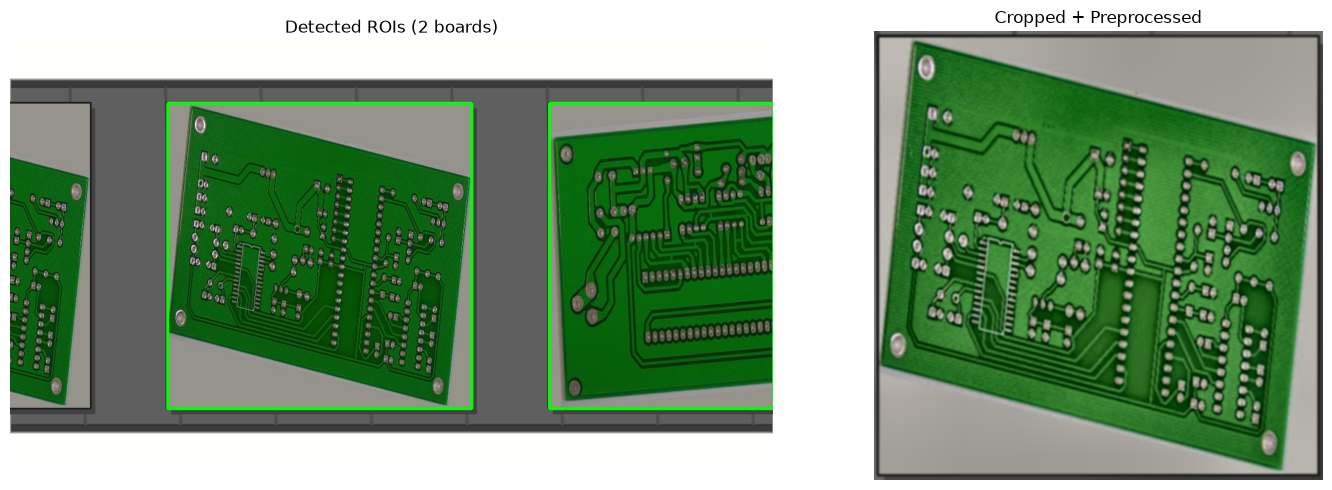

In [28]:
video_file = "PCB_Conveyor.mp4"    # adjust the path if needed

cap = cv2.VideoCapture(video_file)
cap.set(cv2.CAP_PROP_POS_FRAMES, 300)
ok, frame = cap.read()
cap.release()

if ok:
    boxes = find_pcb_regions(frame)
    print("Boards detected:", len(boxes))

    marked = frame.copy()

    for (x, y, w, h) in boxes:
        cv2.rectangle(marked, (x, y), (x + w, y + h), (0, 255, 0), 3)

    board, was_cropped, message = prepare_board(frame)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(marked, cv2.COLOR_BGR2RGB))
    plt.title(f"Detected ROIs ({len(boxes)} boards)")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(board, cv2.COLOR_BGR2RGB))
    plt.title("Cropped + Preprocessed")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

else:
    print("Could not read the video:", video_file)

### Tuning

If the boxes are wrong on your real data:

- **Boards missed** — lower `SAT_THRESHOLD` (try 20). A dark or dusty board is
  less saturated than a clean green one.
- **Two boards merge into one box** — reduce the `MORPH_CLOSE` iterations from 3 to 1.
- **Belt picked up as a board** — raise `SAT_THRESHOLD`, or raise `min_area_frac`.
- **A clean upload gets cropped when it should not** — raise `min_keep` toward 0.95.

If the real production conveyor is **green**, saturation will no longer separate the
board from the belt — `_pcb_mask` would need to reject the belt by hue instead.

# Experiments for Section 2.1

Comparisons, each **within a single category** so that the algorithms being
compared actually do the same job:

| Group | Compared | Category |
|---|---|---|
| 1 | Gaussian vs Median | noise reduction |
<!-- | 2 | CLAHE vs Histogram Equalisation | contrast enhancement | -->

## Group 1 — Noise Reduction: Gaussian vs Median

Two noise types are tested, because each filter has a different speciality and testing
only one would give a biased result:

In [29]:
def add_gaussian_noise(img, sigma=18, seed=0):
    rng = np.random.default_rng(seed)
    noisy = img.astype(np.int16) + rng.normal(0, sigma, img.shape)
    return np.clip(noisy, 0, 255).astype(np.uint8)


# def add_salt_pepper(img, amount=0.02, seed=0):
#     rng = np.random.default_rng(seed)
#     out = img.copy()
#     m = rng.random(img.shape[:2])
#     out[m < amount] = 0                  # pepper
#     out[m > 1 - amount] = 255             # salt
#     return out


def edge_energy(img):
    """Laplacian variance. Falls when a filter smooths defect boundaries away."""
    return float(cv2.Laplacian(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), cv2.CV_64F).var())


print("Noise models loaded.")

Noise models loaded.


In [37]:
import time
import pandas as pd

NOISE_TYPES = [
    ("Gaussian noise (sigma=18)", add_gaussian_noise),
]

FILTERS = [
    ("Gaussian 5x5", lambda x: cv2.GaussianBlur(x, (5, 5), 0)),
    ("Median 5",     lambda x: cv2.medianBlur(x, 5)),
]

results_noise = []

for noise_name, noise_fn in NOISE_TYPES:

    psnr = {n: [] for n, _ in FILTERS}
    kept = {n: [] for n, _ in FILTERS}

    for cls, file in [images[0]]:

        clean = cv2.imread(
            os.path.join(input_folder, cls, file)
        )

        if clean is None:
            continue

        e_clean = edge_energy(clean)

        noisy = noise_fn(clean)

        for name, fn in FILTERS:

            out = fn(noisy)

            psnr[name].append(
                cv2.PSNR(clean, out)
            )

            kept[name].append(
                100 * edge_energy(out) / e_clean
            )

    for name, _ in FILTERS:

        results_noise.append({
            "Noise Type": noise_name,
            "Filter": name,
            "Average PSNR (dB)": np.mean(psnr[name]),
            "Average Edge Kept (%)": np.mean(kept[name])
        })


# Create table
noise_table = pd.DataFrame(results_noise)

noise_table["Average PSNR (dB)"] = noise_table[
    "Average PSNR (dB)"
].round(2)

noise_table["Average Edge Kept (%)"] = noise_table[
    "Average Edge Kept (%)"
].round(2)

noise_table

,Noise Type,Filter,Average PSNR (dB),Average Edge Kept (%)
0,Gaussian noise (sigma=18),Gaussian 5x5,26.72,4.05
1,Gaussian noise (sigma=18),Median 5,25.32,6.51


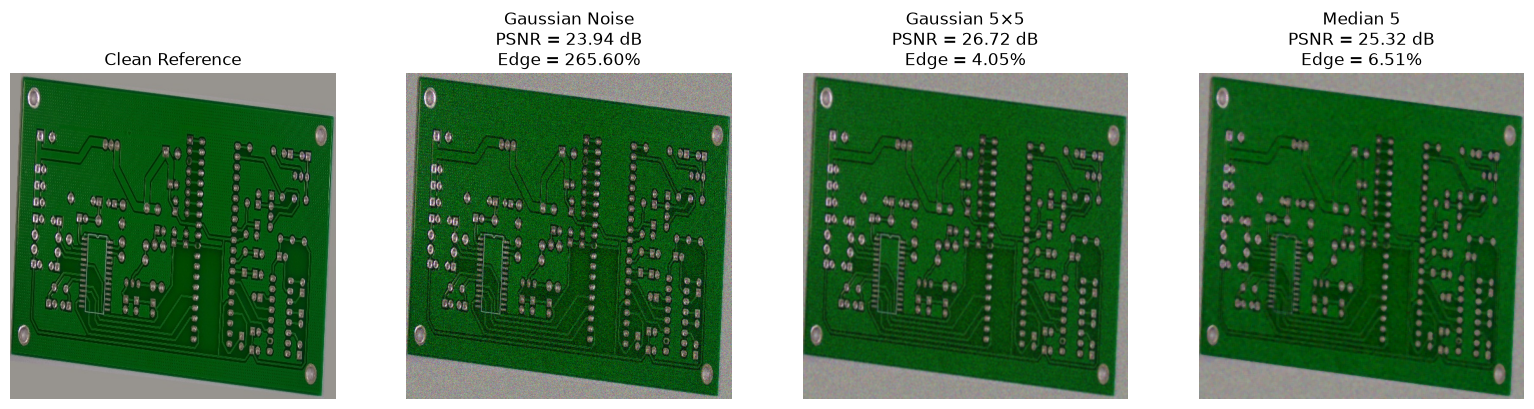

In [38]:
img = cv2.imread(
    os.path.join(
        input_folder,
        images[0][0],
        images[0][1]
    )
)

noisy = add_gaussian_noise(
    img,
    sigma=18,
    seed=0
)

e_clean = edge_energy(img)

panels = [
    ("Clean Reference", img),
    ("Gaussian Noise", noisy),
    ("Gaussian 5×5", FILTERS[0][1](noisy)),
    ("Median 5", FILTERS[1][1](noisy))
]

plt.figure(figsize=(16, 4))

for i, (title, image) in enumerate(panels):

    plt.subplot(1, 4, i + 1)

    plt.imshow(
        cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )
    )

    if i >= 1:
        psnr_value = cv2.PSNR(
            img,
            image
        )

        edge_value = (
            100 *
            edge_energy(image) /
            e_clean
        )

        plt.title(
            f"{title}\n"
            f"PSNR = {psnr_value:.2f} dB\n"
            f"Edge = {edge_value:.2f}%"
        )

    else:
        plt.title(title)

    plt.axis("off")

plt.tight_layout()
plt.show()

## Group 2 — Contrast Enhancement: CLAHE vs Histogram Equalisation

Both are applied to the **L channel**  Gaussian filtering
Four metrics：

| Metric | Meaning | Higher better? |
|---|---|---|
| Std dev | the number usually quoted as "contrast" | **not on its own** |
| Entropy | information content in bits | yes |
| Noise | Laplacian variance, i.e. amplified high frequencies | no |
| Time | ms per image | no |

In [35]:
import pandas as pd
import time

def image_entropy(channel):

    hist = cv2.calcHist(
        [channel],
        [0],
        None,
        [256],
        [0, 256]
    ).ravel()

    p = hist / hist.sum()

    p = p[p > 0]

    return float(
        -(p * np.log2(p)).sum()
    )


def noise_level(channel):

    return float(
        cv2.Laplacian(
            channel,
            cv2.CV_64F
        ).var()
    )


METHODS = [
    (
        "Original",
        lambda L: L
    ),
    (
        "Histogram Equalisation",
        lambda L: cv2.equalizeHist(L)
    ),
    (
        "CLAHE",
        lambda L: cv2.createCLAHE(
            clipLimit=2.0,
            tileGridSize=(8, 8)
        ).apply(L)
    )
]


results_contrast = []

for cls, file in [images[0]]:

    img = cv2.imread(
        os.path.join(
            input_folder,
            cls,
            file
        )
    )

    if img is None:
        continue

    # Same preprocessing before comparison
    norm = cv2.normalize(
        img,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    )

    blur = cv2.GaussianBlur(
        norm,
        (5, 5),
        0
    )

    lab = cv2.cvtColor(
        blur,
        cv2.COLOR_BGR2LAB
    )

    L = cv2.split(lab)[0]

    for name, fn in METHODS:

        output = fn(L)

        results_contrast.append({

            "Method": name,

            "Standard Deviation": output.std(),

            "Entropy": image_entropy(output),

            "Noise Level": noise_level(output)
        })


contrast_table = pd.DataFrame(
    results_contrast
)

# Average results
contrast_summary = (
    contrast_table
    .groupby("Method")
    .mean()
    .reset_index()
)

contrast_summary["Standard Deviation"] = (
    contrast_summary["Standard Deviation"]
    .round(2)
)

contrast_summary["Entropy"] = (
    contrast_summary["Entropy"]
    .round(2)
)

contrast_summary["Noise Level"] = (
    contrast_summary["Noise Level"]
    .round(2)
)

contrast_summary

,Method,Standard Deviation,Entropy,Noise Level
0,CLAHE,41.28,7.08,250.45
1,Histogram Equalisation,76.42,5.42,1993.71
2,Original,34.28,5.59,63.08


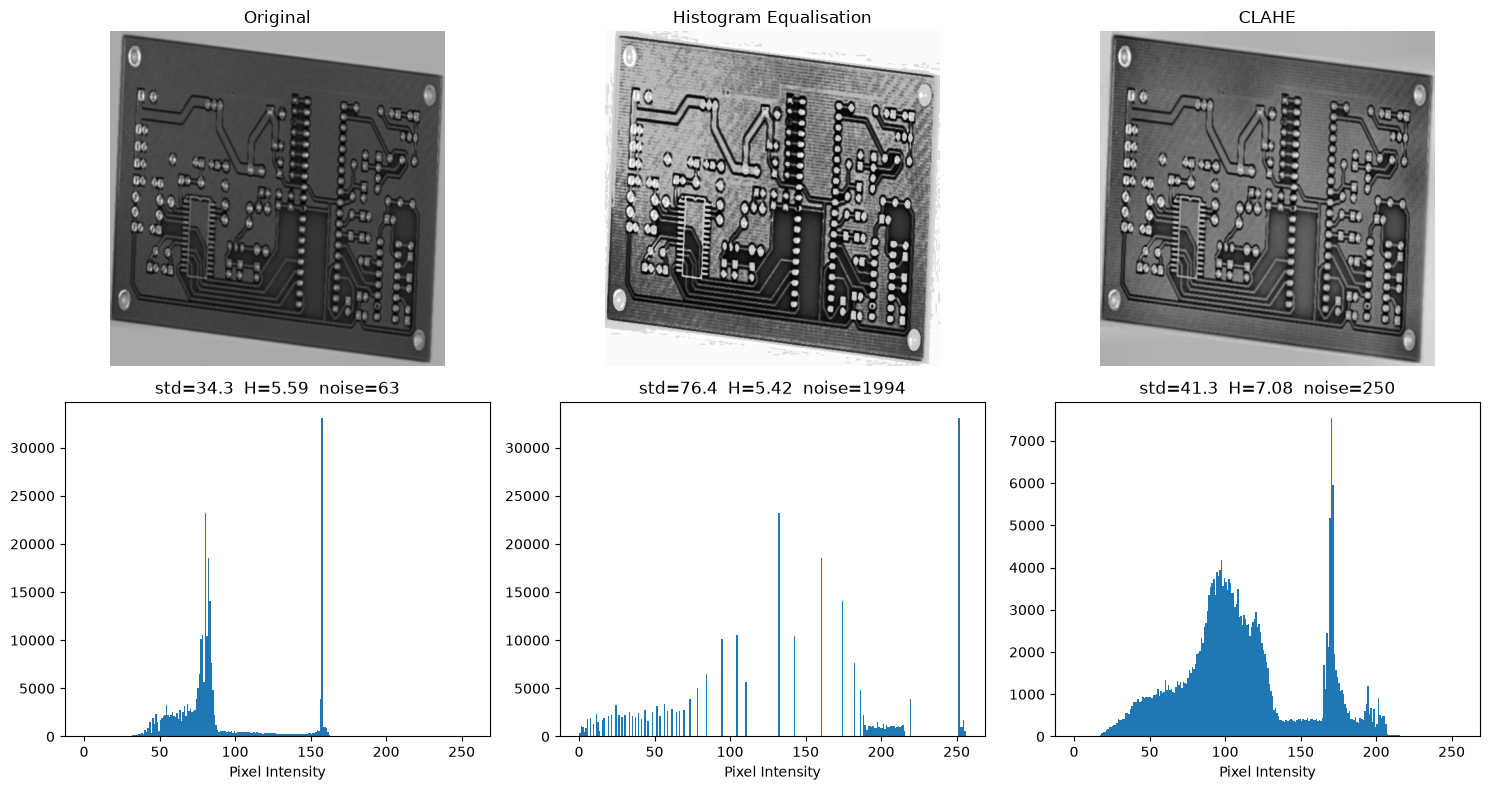

In [33]:
# Visual comparison for the report
img = cv2.imread(os.path.join(input_folder, images[0][0], images[0][1]))

norm = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)
blur = cv2.GaussianBlur(norm, (5, 5), 0)
L = cv2.split(cv2.cvtColor(blur, cv2.COLOR_BGR2LAB))[0]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, (name, fn) in enumerate(METHODS):
    out = fn(L)

    axes[0, i].imshow(out, cmap="gray")
    axes[0, i].set_title(name)
    axes[0, i].axis("off")

    axes[1, i].hist(out.ravel(), bins=256, range=(0, 256))
    axes[1, i].set_title(f"std={out.std():.1f}  H={image_entropy(out):.2f}  "
                         f"noise={noise_level(out):.0f}")
    axes[1, i].set_xlabel("Pixel Intensity")

plt.tight_layout()
plt.show()